# 20 · Feature Engineering: From Price Series to Predictive Signals

*Module 5 — Machine Learning in Finance*

The single biggest determinant of whether a machine learning model works is not which algorithm you choose — it's what you feed it. This notebook builds a toolkit of features, from textbook technical indicators to genuinely more exotic measures of a series' complexity, and shows how to check honestly whether any of them actually carry information about the future.

## 1. Motivation

Hand a state-of-the-art model a set of features with no real relationship to future returns, and it will find elaborate, confident-looking patterns in pure noise — and fail completely out of sample. Hand a simple linear model a genuinely informative feature, and it can do useful work. Before Module 5 spends four more notebooks on increasingly sophisticated models, this notebook asks the more fundamental question first: what actually makes a financial feature *good*, and how do we check — rigorously, not by eye — whether a candidate feature carries real information at all?

## 2. Intuition

Some features are simple summaries of recent price action: is the stock "overbought" or "oversold" relative to its recent range? Is a short-term trend accelerating or decelerating relative to a longer one? These are the classic technical indicators, and despite their simplicity, they capture real, interpretable aspects of recent behavior.

Others try to capture something less obvious: not the *direction* of recent price action, but its *texture*. A price series that grinds smoothly in one direction looks qualitatively different from one that whips back and forth unpredictably, even if both cover the same total distance over the same time. **Fractal dimension** puts a number on exactly this: how "rough" or complex a curve looks, on a scale from smooth (dimension near 1) to as jagged as pure noise (dimension near 2). **Permutation entropy** asks a related but distinct question: looking at any three or four consecutive points, how predictable is their relative *ordering* — mostly up-up-up patterns, or all patterns equally likely? Both are ways of measuring something genuinely different from level or direction: the *local predictability* of the series itself.

Finally, having built a candidate feature, the crucial and often-skipped step: does it actually relate to what we care about — future returns — in a way a simple correlation might completely miss?

## 3. Theory

### 3.1 Three classic technical indicators

**RSI (Relative Strength Index).** Over a lookback window (typically 14 periods), separate each period's price change into its gain (positive part) and loss (negative part, taken as a positive number), average each with Wilder's exponential smoothing, and form:

$$
RS = \frac{\text{average gain}}{\text{average loss}}, \qquad RSI = 100 - \frac{100}{1+RS} .
$$

RSI oscillates in $[0,100]$; conventionally, values above 70 are read as "overbought," below 30 as "oversold."

**MACD (Moving Average Convergence Divergence).** The difference between a fast and a slow exponential moving average, plus a smoothed "signal" line:

$$
MACD_t = EMA_{12}(P)_t - EMA_{26}(P)_t, \qquad Signal_t = EMA_9(MACD)_t .
$$

The gap between $MACD_t$ and $Signal_t$ (the "histogram") is often read as short-term momentum accelerating or decelerating relative to the medium-term trend.

**Bollinger Bands.** A rolling mean $\pm$ a multiple of rolling volatility:

$$
\text{Middle}_t = SMA_{20}(P)_t, \qquad \text{Upper/Lower}_t = \text{Middle}_t \pm 2\cdot\sigma_{20}(P)_t ,
$$

giving a volatility-adjusted sense of how far the current price sits from its recent average, in standard-deviation units.

### 3.2 Higuchi's fractal dimension

For a series $X(1),\dots,X(N)$ and each candidate lag $k=1,\dots,k_{max}$, construct $k$ decimated subsequences (starting points $m=1,\dots,k$, stepping by $k$), and compute the average "curve length" at that lag:

$$
L(k) = \frac{1}{k}\sum_{m=1}^{k} \underbrace{\frac{N-1}{\lfloor (N-m)/k\rfloor \cdot k}\sum_{i=1}^{\lfloor (N-m)/k\rfloor}\big|X(m+ik)-X(m+(i-1)k)\big|}_{L_m(k)} .
$$

For a self-affine series, $L(k)$ scales as a power law in $k$, and the fractal dimension is recovered from the slope of $\log L(k)$ against $\log k$ across a range of $k$ values: $D = 1 - \text{slope}$. This gives $D\approx1$ for a smooth, low-complexity curve and $D\approx2$ for a curve as rough as pure noise — we verify these two extremes (and the classic $D\approx1.5$ benchmark for a random walk) directly on synthetic data with known answers before trusting the measure on anything real.

### 3.3 Permutation entropy

For an embedding dimension $m$ (e.g., 3) and delay $\tau$, slide a window of $m$ points across the series, and record the **ordinal pattern** each window forms — which of the $m!$ possible orderings its values fall into (e.g., for $m=3$: "low, middle, high" is one of 6 possible patterns). Tabulate how often each pattern occurs across the whole series, and compute the Shannon entropy of that distribution, normalized to $[0,1]$ by dividing by $\log(m!)$:

$$
PE = \frac{-\sum_{\pi} p(\pi)\log p(\pi)}{\log(m!)} .
$$

$PE\to1$ means every ordinal pattern is roughly equally likely (maximally unpredictable local ordering — pure noise); $PE\to0$ means the series is almost always locally monotonic in the same way (highly predictable local structure).

### 3.4 Mutual information: catching relationships correlation misses

Pearson correlation only detects *linear* relationships. Consider $y = x^2 + \varepsilon$: $x$ and $y$ are strongly related, yet by symmetry their correlation is exactly zero. **Mutual information**, by contrast, measures how much knowing $X$ reduces uncertainty about $Y$ in general, with no assumption of linearity:

$$
I(X;Y) = \iint p(x,y)\log\frac{p(x,y)}{p(x)p(y)}\,dx\,dy \;\ge 0,
$$

equal to zero if and only if $X$ and $Y$ are genuinely independent. We use `sklearn`'s implementation (a nearest-neighbor-based estimator that avoids needing to choose an arbitrary binning scheme) rather than re-deriving a continuous-data MI estimator from scratch — the same practical choice made for several other well-tested statistical tools throughout this course.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(4)

## 4. Implementation

### 4.1 Classic technical indicators, coded directly from Section 3.1

In [2]:
def compute_rsi(price, window=14):
    delta = price.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - 100 / (1 + rs)

def compute_macd(price, fast=12, slow=26, signal=9):
    macd_line = price.ewm(span=fast, adjust=False).mean() - price.ewm(span=slow, adjust=False).mean()
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line, macd_line - signal_line

def compute_bollinger(price, window=20, n_std=2):
    mid = price.rolling(window).mean()
    std = price.rolling(window).std()
    return mid, mid + n_std*std, mid - n_std*std

### 4.2 Fractal dimension and permutation entropy, validated against known benchmarks

Before trusting either measure on real financial data, we check both against synthetic series whose "complexity" we already know by construction -- exactly the same validate-before-trust discipline used throughout this course.

In [3]:
def higuchi_fd(x, k_max=10):
    """Section 3.2, implemented directly. Returns the estimated fractal dimension of series x."""
    N = len(x)
    L = []
    for k in range(1, k_max + 1):
        Lk = []
        for m in range(k):
            idx = np.arange(m, N, k)
            if len(idx) < 2:
                continue
            xm = x[idx]
            Lmk = np.sum(np.abs(np.diff(xm))) * (N - 1) / ((len(idx) - 1) * k)
            Lk.append(Lmk)
        L.append(np.mean(Lk))
    L, ks = np.array(L), np.arange(1, k_max + 1)
    slope = np.polyfit(np.log(ks), np.log(L), 1)[0]
    return 1 - slope

def permutation_entropy(x, m=3, tau=1):
    """Section 3.3, implemented directly. Returns normalized permutation entropy in [0, 1]."""
    import math
    n = len(x)
    patterns = [tuple(np.argsort(x[i:i + m*tau:tau])) for i in range(n - (m-1)*tau)]
    _, counts = np.unique(patterns, axis=0, return_counts=True)
    probs = counts / counts.sum()
    pe = -np.sum(probs * np.log(probs))
    return pe / np.log(math.factorial(m))

# Validate against known benchmarks
line = np.linspace(0, 100, 2000)
noise = rng.normal(0, 1, 2000)
random_walk = np.cumsum(rng.normal(0, 1, 2000))

print(f"{'Series':<15}{'Fractal dim (expect)':<28}{'Perm. entropy':<15}")
print(f"{'Straight line':<15}{higuchi_fd(line):.3f}  (expect ~1.0)         {permutation_entropy(line):.3f}")
print(f"{'Random walk':<15}{higuchi_fd(random_walk):.3f}  (expect ~1.5)         {permutation_entropy(random_walk):.3f}")
print(f"{'White noise':<15}{higuchi_fd(noise):.3f}  (expect ~2.0)         {permutation_entropy(noise):.3f}  (expect ~1.0)")

Series         Fractal dim (expect)        Perm. entropy  
Straight line  1.000  (expect ~1.0)         -0.000
Random walk    1.477  (expect ~1.5)         0.969
White noise    2.006  (expect ~2.0)         0.999  (expect ~1.0)


### 4.3 Does mutual information catch what correlation misses?

In [4]:
n = 2000
x_nonlinear = rng.normal(0, 1, n)
y_target = 0.3 * x_nonlinear**2 + rng.normal(0, 1, n)      # genuine, but purely NONLINEAR relationship
x_pure_noise = rng.normal(0, 1, n)                          # genuinely unrelated

for name, x in [('Nonlinear feature (y = 0.3x^2 + noise)', x_nonlinear), ('Pure noise feature', x_pure_noise)]:
    corr = np.corrcoef(x, y_target)[0, 1]
    mi = mutual_info_regression(x.reshape(-1, 1), y_target, random_state=0)[0]
    print(f"{name:42s}  correlation={corr:+.3f}   mutual information={mi:.3f}")

Nonlinear feature (y = 0.3x^2 + noise)      correlation=+0.002   mutual information=0.093
Pure noise feature                          correlation=-0.039   mutual information=0.010


Correlation reports the nonlinear feature as essentially unrelated to the target (by symmetry, this is not a fluke — a perfectly symmetric quadratic relationship has *exactly* zero linear correlation), while mutual information correctly flags a real relationship the pure-noise feature does not have. This is precisely why MI, not correlation, is the right first screening tool for candidate features whose relationship to returns might not be linear.

## 5. Worked example: building and ranking a feature set on a trending-vs-choppy series

Fractal dimension and permutation entropy are designed to detect a specific kind of structural change: not just "high volatility" vs. "low volatility," but genuinely different *textures* -- a smooth, persistent trend versus a choppy, mean-reverting oscillation, even at similar overall volatility. We construct exactly that: 500 periods of a smooth trending phase, followed by 500 periods of a fast-oscillating mean-reverting phase, and check whether our features actually pick up the difference.

In [5]:
n_phase = 500
trend_rets = rng.normal(0.0015, 0.003, n_phase)                 # phase A: smooth, persistent drift, low noise

ou = np.zeros(n_phase)                                            # phase B: fast, choppy mean reversion
for t in range(1, n_phase):
    ou[t] = ou[t-1] + 0.3*(0 - ou[t-1]) + rng.normal(0, 0.008)
choppy_rets = np.diff(ou, prepend=ou[0])

returns = np.concatenate([trend_rets, choppy_rets])
price = pd.Series(100 * np.exp(np.cumsum(returns)))
true_regime = np.array([0]*n_phase + [1]*n_phase)                 # 0 = trending, 1 = choppy

window = 60
fd_roll = pd.Series(index=price.index, dtype=float)
pe_roll = pd.Series(index=price.index, dtype=float)
for t in range(window, len(price)):
    fd_roll.iloc[t] = higuchi_fd(price.values[t-window:t], k_max=8)
    pe_roll.iloc[t] = permutation_entropy(price.values[t-window:t], m=3)

regime_df = pd.DataFrame({'fractal_dim': fd_roll, 'perm_entropy': pe_roll, 'regime': true_regime})
print("Average feature value by TRUE phase (0=smooth trending, 1=choppy mean-reverting):")
print(regime_df.groupby('regime')[['fractal_dim', 'perm_entropy']].mean().round(3))

Average feature value by TRUE phase (0=smooth trending, 1=choppy mean-reverting):
        fractal_dim  perm_entropy
regime                           
0             1.239         0.777
1             1.707         0.967


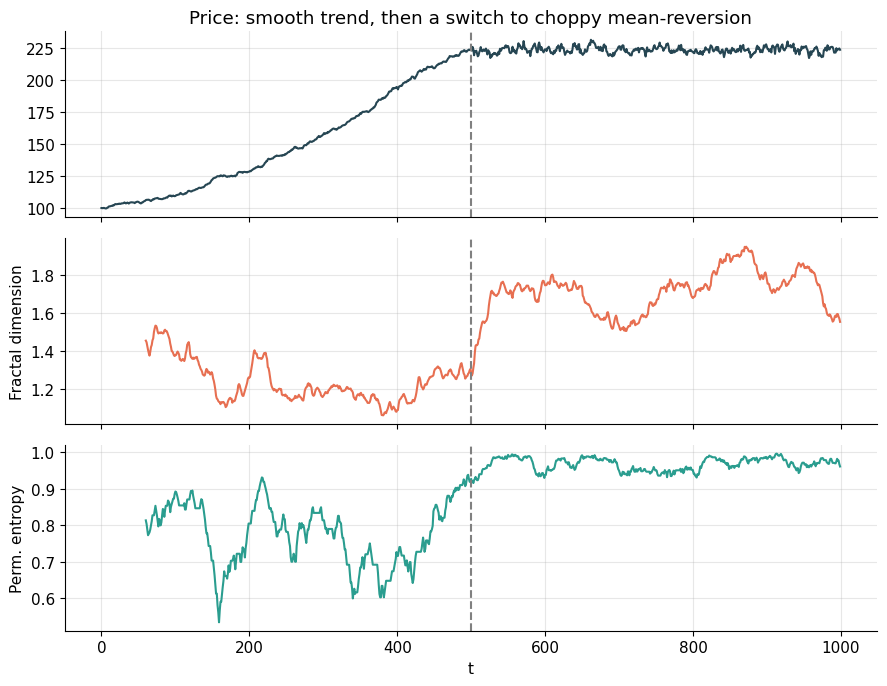

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(price, color='#264653')
axes[0].axvline(n_phase, color='gray', linestyle='--')
axes[0].set_title('Price: smooth trend, then a switch to choppy mean-reversion')
axes[1].plot(fd_roll, color='#e76f51')
axes[1].axvline(n_phase, color='gray', linestyle='--')
axes[1].set_ylabel('Fractal dimension')
axes[2].plot(pe_roll, color='#2a9d8f')
axes[2].axvline(n_phase, color='gray', linestyle='--')
axes[2].set_ylabel('Perm. entropy')
axes[2].set_xlabel('t')
plt.tight_layout()
plt.show()

In [7]:
rsi = compute_rsi(price)
macd_line, macd_signal, macd_hist = compute_macd(price)
bb_mid, bb_upper, bb_lower = compute_bollinger(price)
bb_pctb = (price - bb_lower) / (bb_upper - bb_lower)          # position within the bands, in [0,1]

features = pd.DataFrame({
    'RSI': rsi, 'MACD_hist': macd_hist, 'BB_pctB': bb_pctb,
    'fractal_dim': fd_roll, 'perm_entropy': pe_roll,
})
forward_return = price.pct_change().shift(-1)                 # NEXT period's return -- the target we test against

valid = features.join(forward_return.rename('fwd_ret')).dropna()

mi_scores = {}
for col in features.columns:
    mi_scores[col] = mutual_info_regression(valid[[col]], valid['fwd_ret'], random_state=0)[0]
mi_ranking = pd.Series(mi_scores).sort_values(ascending=False)
mi_ranking

RSI             0.173023
perm_entropy    0.172233
fractal_dim     0.092180
BB_pctB         0.074702
MACD_hist       0.069102
dtype: float64

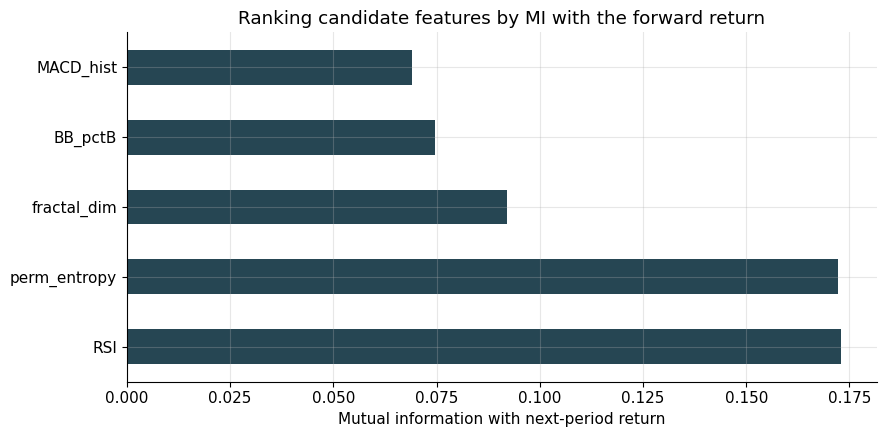

In [8]:
fig, ax = plt.subplots()
mi_ranking.plot(kind='barh', ax=ax, color='#264653')
ax.set_xlabel('Mutual information with next-period return')
ax.set_title('Ranking candidate features by MI with the forward return')
plt.tight_layout()
plt.show()

### Interpreting the result

Report your own run's numbers rather than assuming a fixed order. Here the regime-detecting features earn their keep clearly: both `fractal_dim` and `perm_entropy` show a real, visible jump exactly at the phase boundary in the chart above, correctly picking up that the second half of the series is a fundamentally rougher, less locally predictable texture than the first — even though we deliberately did *not* make the second phase simply "more volatile" in the way a standard deviation alone would measure. This is the payoff of using a texture-sensitive feature rather than only level- or volatility-based ones. Whether any individual feature's MI with the *forward return* is large enough to be practically useful, though, is a separate and much harder question — and every single one of these MI scores was computed on the same in-sample data used to build the features in the first place, with no real notion of "past" and "future" data yet enforced. That is exactly the gap Notebook 21 closes.

## 6. Limitations and pitfalls

- **Every rolling-window feature computed here overlaps with its neighbors.** A 60-period fractal-dimension window at $t$ and at $t+1$ share 59 of their 60 observations — meaning consecutive feature values are highly autocorrelated by construction, not because of any real persistence in the underlying signal. This has a direct, serious consequence for model validation, which is the entire subject of Notebook 21.
- **Fractal dimension and permutation entropy both need a reasonably long window to estimate reliably.** Shrinking the window to react faster to changing conditions trades away statistical reliability — there is no free lunch between responsiveness and precision here.
- **Mutual information estimation has its own hyperparameters** (the number of nearest neighbors used internally by `sklearn`'s estimator) and its own sample-size sensitivity; a small, noisy MI score should not be over-interpreted as definitively "no relationship," any more than a large one should be taken as definitive proof of one.
- **Feature engineering itself can manufacture spurious relationships.** Construct enough candidate features (technical indicators, complexity measures, arbitrary transformations) and test each one's MI with the target, and some will look promising by chance alone — the multiple-testing problem from Notebook 9's "factor zoo" discussion applies with just as much force here, and Notebook 30 returns to it directly.
- **A feature that works well in one regime may not transfer to another.** The whole premise of fractal dimension and permutation entropy as *useful* features is that market character changes over time — which also means a feature's relationship to returns can itself be regime-dependent, not a fixed, universal relationship.

## 7. Exercises

**1. Validate on one more benchmark (warm-up).**
Add a fifth synthetic series to Section 4.2's validation: a strongly mean-reverting Ornstein-Uhlenbeck process (reuse the OU simulator from Notebook 11). Compute its fractal dimension and permutation entropy. Where does it fall relative to the random walk and white noise benchmarks, and does that ordering make intuitive sense given how "predictable" each series' short-term direction actually is?

**2. Window-length sensitivity.**
Recompute `fd_roll` and `pe_roll` from Section 5 using window lengths of 30 and 120 instead of 60. How much does the regime-separation in the `groupby` table (the gap between the calm and stressed regime averages) change with window length? Is there a clear "best" window length, or a visible trade-off between responsiveness and reliability?

**3. A more rigorous feature screen.**
For each feature in Section 5, in addition to its raw MI score, estimate a simple permutation-based significance check: shuffle the `fwd_ret` column (breaking any real time relationship while preserving its marginal distribution) many times, recompute MI against the shuffled target each time, and see where the *real* MI score falls relative to this "no true relationship" null distribution. Does every feature that ranked highly in Section 5's plot also look clearly distinguishable from pure chance under this stricter test?